# **1. 드라이브 연결**

In [1]:
from google.colab import drive
import os

drive.mount('/content/drive')

Mounted at /content/drive


# **2. 모델 및 함수 정의**

In [2]:
import os
import pandas as pd
import torch
import torch.nn as nn
import pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import DataLoader, TensorDataset
import warnings
warnings.filterwarnings('ignore')

# GPU/CPU 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Using device: {device}")


# CasualConv1d layer
# 과거-현재 데이터만 보고 특징을 추출함
class CausalConv1d(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, dilation=1):
        super(CausalConv1d, self).__init__()
        self.padding = (kernel_size - 1) * dilation
        self.conv = nn.Conv1d(in_channels, out_channels, kernel_size,
                              padding=self.padding, dilation=dilation)

    def forward(self, x):
        x = self.conv(x)
        return x[:, :, :-self.padding]

class TemporalConvNet(nn.Module):
    def __init__(self, num_inputs, num_channels, kernel_size=3, dropout=0.2):
        super(TemporalConvNet, self).__init__()
        layers = []
        num_levels = len(num_channels)
        for i in range(num_levels):
            dilation_size = 2 ** i
            in_channels = num_inputs if i == 0 else num_channels[i-1]
            out_channels = num_channels[i]
            layers += [
                CausalConv1d(in_channels, out_channels, kernel_size, dilation=dilation_size),
                nn.ReLU(),
                nn.Dropout(dropout)
            ]
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

class TRACE_GPT(nn.Module):
    def __init__(self, num_sensors, seq_len, d_model=128, n_head=8, num_layers=6, resolution=100, dropout=0.1):
        super(TRACE_GPT, self).__init__()
        self.num_sensors = num_sensors
        self.seq_len = seq_len
        self.resolution = resolution
        self.d_model = d_model

        # TCN 4층 (Receptive Field 확보)
        tcn_channels = [d_model] * 4

        self.tcn = TemporalConvNet(
            num_inputs=num_sensors + 1, # +1 for Time Index
            num_channels=tcn_channels,
            kernel_size=3,
            dropout=dropout
        )

        self.transformer_encoder = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(d_model=d_model, nhead=n_head, batch_first=True, dropout=dropout),
            num_layers=num_layers
        )

        self.output_head = nn.Linear(d_model, num_sensors * resolution)

    def _generate_square_subsequent_mask(self, sz):
        mask = (torch.triu(torch.ones(sz, sz)) == 1).transpose(0, 1)
        mask = mask.float().masked_fill(mask == 0, float('-inf')).masked_fill(mask == 1, float(0.0))
        return mask

    def forward(self, x):
        batch_size, curr_seq_len, _ = x.size()

        # Positional Embedding
        steps = torch.arange(curr_seq_len, device=x.device, dtype=torch.float32)
        time_idx = (steps / self.seq_len).unsqueeze(0).unsqueeze(2)
        time_idx = time_idx.expand(batch_size, -1, -1)

        x_emb = torch.cat([x, time_idx], dim=2)

        x_tcn = x_emb.permute(0, 2, 1)
        x_tcn = self.tcn(x_tcn)
        x_tcn = x_tcn.permute(0, 2, 1)

        tgt_mask = self._generate_square_subsequent_mask(curr_seq_len).to(x.device)
        output = self.transformer_encoder(x_tcn, mask=tgt_mask, is_causal=True)

        logits = self.output_head(output)
        logits = logits.view(batch_size, curr_seq_len, self.num_sensors, self.resolution)

        return logits


def preprocess_and_window(df_wafer, sensor_cols, seq_len, scaler):
    """실시간 Raw 데이터를 스케일링하고 슬라이딩 윈도우 텐서로 변환"""
    data_values = df_wafer[sensor_cols].values
    data_scaled = scaler.transform(data_values) # 저장된 scaler로 변환

    sequences = []
    if len(data_scaled) < seq_len:
        print(f"⚠️ 데이터 길이가 시퀀스 길이({seq_len})보다 짧아 처리할 수 없습니다.")
        return None

    for i in range(len(data_scaled) - seq_len + 1):
        sequences.append(data_scaled[i : i + seq_len])

    return torch.FloatTensor(np.array(sequences)) # [Window_Num, 32, 19]


# 변환 함수
# 0~1 사이의 실수 데이터를 0~99 사이의 정수 데이터로 변환
def quantize_data(x, resolution=100):
    x_idx = (x * (resolution - 1)).long()
    x_idx = torch.clamp(x_idx, 0, resolution - 1)
    return x_idx


# 학습 함수
def train_trace_gpt(model, train_loader, optimizer, epoch, device, resolution=100):
    model.train()
    total_loss = 0
    criterion = nn.CrossEntropyLoss()

    for (data,) in train_loader:
        data = data.to(device)
        optimizer.zero_grad()

        # Input(0~T-1) -> Target(1~T): 데이터 분할
        input_seq = data[:, :-1, :]
        target_seq = data[:, 1:, :]
        target_idx = quantize_data(target_seq, resolution)

        output_logits = model(input_seq)

        # loss 계산 (모델의 예측과 실제 정답 간의 차이)
        loss = criterion(
            output_logits.reshape(-1, resolution),
            target_idx.reshape(-1)
        )
        # 가중치 업데이트
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    if (epoch + 1) % 10 == 0: # 10 epoch마다 로그 출력
        print(f"Epoch [{epoch+1}] Loss: {avg_loss:.4f}")
    return avg_loss

def trace_calculate_window_scores(model, data_tensor, device, batch_size=32, resolution=100):
    model.eval()
    all_scores = []
    criterion = nn.CrossEntropyLoss(reduction='none')   # loss 계산

    dataset = TensorDataset(data_tensor)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

    with torch.no_grad():
        for (data,) in loader:
            data = data.to(device)
            input_seq = data[:, :-1, :]   # 입력 데이터
            target_seq = data[:, 1:, :]   # 정답 데이터
            target_idx = quantize_data(target_seq, resolution)    # 정답 데이터를 0~99로 변환

            output_logits = model(input_seq)    # 모델이 예측한 확률값

            loss_element = criterion(
                output_logits.reshape(-1, resolution),
                target_idx.reshape(-1)
            )
            loss_element = loss_element.view(input_seq.shape[0], input_seq.shape[1], input_seq.shape[2])

            # Window별 평균 Loss
            score_window = loss_element.mean(dim=[1, 2])
            all_scores.extend(score_window.cpu().numpy())

    return np.array(all_scores)



def trace_calculate_rca_scores(model, data_tensor, device, batch_size=32, resolution=100):
    model.eval()
    all_scores = []
    criterion_none = nn.CrossEntropyLoss(reduction='none')
    loader = DataLoader(TensorDataset(data_tensor), batch_size=batch_size, shuffle=False)
    with torch.no_grad():
        for (data,) in loader:
            data = data.to(device)
            input_seq, target_seq = data[:, :-1, :], data[:, 1:, :]
            target_idx = quantize_data(target_seq, resolution)
            logits = model(input_seq)
            loss_elem = criterion_none(logits.reshape(-1, resolution), target_idx.reshape(-1))
            loss_elem = loss_elem.view(input_seq.shape[0], input_seq.shape[1], input_seq.shape[2])
            all_scores.append(loss_elem.mean(dim=1).cpu().numpy()) # [시간] 축만 평균, [센서] 차원 보존
    return np.concatenate(all_scores, axis=0)

def analyze_single_wafer(model, wafer_tensor, wafer_id, threshold, sensor_cols, device, resolution=100):
    print(f"\n" + "="*55)
    print(f" 🏭 Wafer Analysis Report: [ {wafer_id} ]")
    print("="*55)

    window_scores = trace_calculate_window_scores(model, wafer_tensor, device, batch_size=32, resolution=resolution)
    wafer_score = np.max(window_scores)

    print(f"▶ Wafer Anomaly Score: {wafer_score:.4f} (기준 임계값: {threshold:.4f})")

    if wafer_score > threshold:
        print(f"▶ 판정: 불량 (Fault) 감지")
        print("-" * 55)
        print("[Root Cause Analysis]")

        rca_scores = trace_calculate_rca_scores(model, wafer_tensor, device, batch_size=32, resolution=resolution)
        wafer_sensor_scores = rca_scores.mean(axis=0)

        top_k = 5
        top_indices = np.argsort(wafer_sensor_scores)[::-1][:top_k]
        top_sensors = [sensor_cols[i] for i in top_indices]
        top_scores = wafer_sensor_scores[top_indices]

        plt.figure(figsize=(8, 4))
        sns.barplot(x=top_scores, y=top_sensors, palette='Reds_r')
        plt.title(f"RCA - Top {top_k} Anomalous Sensors ({wafer_id})", fontweight='bold')
        plt.xlabel("Anomaly Score (Loss)")
        plt.ylabel("Sensors")
        plt.tight_layout()
        plt.show()

        for i, (sensor, score) in enumerate(zip(top_sensors, top_scores)):
            print(f"  {i+1}위. {sensor}: {score:.4f}")
    else:
        print(f"▶ 판정: ✅ 정상 (Normal)")
        print("▶ 해당 웨이퍼는 안정적인 공정 패턴을 보입니다. (RCA 생략)")

✅ Using device: cpu


# **3. 예측 실행**

In [3]:
import pickle
import numpy as np

TARGET_EXP_ID = 'l33'
save_dir = "/content/drive/MyDrive/ASK_2026_FDC/Code/최종 코드/Saved"


model_path = f"{save_dir}/trace_gpt_{TARGET_EXP_ID}.pth"
meta_path = f"{save_dir}/metadata_{TARGET_EXP_ID}.pkl"

with open(meta_path, 'rb') as f:
    loaded_meta = pickle.load(f)

# 정상 웨이퍼 ID 목록 출력
normal_wafers = np.unique(loaded_meta['ids_test_norm'])
print(f"✅ [{TARGET_EXP_ID} 실험군] 테스트용 정상 웨이퍼 목록 (총 {len(normal_wafers)}개):")
print(normal_wafers)

print("-" * 50)

# 덤으로 불량 웨이퍼 ID 목록도 출력해보기
fault_wafers = np.unique(loaded_meta['ids_test_fault'])
print(f"🚨 [{TARGET_EXP_ID} 실험군] 테스트용 불량 웨이퍼 목록 (총 {len(fault_wafers)}개):")
print(fault_wafers)

✅ [l33 실험군] 테스트용 정상 웨이퍼 목록 (총 15개):
['l3326.txm' 'l3327.txm' 'l3328.txm' 'l3329.txm' 'l3330.txm' 'l3331.txm'
 'l3332.txm' 'l3333.txm' 'l3334.txm' 'l3335.txm' 'l3336.txm' 'l3337.txm'
 'l3338.txm' 'l3342.txm' 'l3343.txm']
--------------------------------------------------
🚨 [l33 실험군] 테스트용 불량 웨이퍼 목록 (총 6개):
['l3318.txm' 'l3319.txm' 'l3320.txm' 'l3339.txm' 'l3340.txm' 'l3341.txm']


In [5]:
TARGET_EXP_ID = 'l33'
TARGET_WAFER = 'l3335.txm'
save_dir = "/content/drive/MyDrive/ASK_2026_FDC/Code/최종 코드/Saved"
data_file_path = "/content/drive/MyDrive/ASK_2026_FDC/Dataset/MACHINE_Data.xlsx" # 원본 데이터 경로

model_path = f"{save_dir}/trace_gpt_{TARGET_EXP_ID}.pth"
meta_path = f"{save_dir}/metadata_{TARGET_EXP_ID}.pkl"

if not os.path.exists(model_path) or not os.path.exists(meta_path):
    print("❌ 저장된 모델/메타데이터가 없습니다.")
else:
    # 1. 메타데이터 (Threshold, Scaler 포함) 로드
    with open(meta_path, 'rb') as f:
        loaded_meta = pickle.load(f)

    config = loaded_meta['config']
    threshold = loaded_meta['threshold']
    sensor_cols = loaded_meta['sensor_cols']
    scaler = loaded_meta['scaler']
    SEQ_LEN = 32

    # 2. 모델 로드 및 가중치 주입
    loaded_model = TRACE_GPT(
        num_sensors=len(sensor_cols), seq_len=SEQ_LEN-1,
        d_model=config['d_model'], resolution=config['resolution']
    ).to(device)
    loaded_model.load_state_dict(torch.load(model_path, map_location=device))
    loaded_model.eval()

    # 3. 원본 데이터에서 타겟 웨이퍼 Raw Data 추출
    print(f"원본 데이터 로드 중: {data_file_path}")
    raw_df = pd.read_excel(data_file_path) if data_file_path.endswith('.xlsx') else pd.read_csv(data_file_path)
    target_df = raw_df[raw_df['Wafer_ID'] == TARGET_WAFER]

    if target_df.empty:
        print(f"❌ 원본 데이터에서 '{TARGET_WAFER}' 웨이퍼를 찾을 수 없습니다.")
    else:
        # 4. 실시간 전처리 (Scaling & Windowing)
        print("⚙️ 데이터 스케일링 및 슬라이딩 윈도우 변환 중...")
        target_tensor = preprocess_and_window(target_df, sensor_cols, SEQ_LEN, scaler)

        # 5. 분석 실행
        if target_tensor is not None:
            target_tensor = target_tensor.to(device)
            analyze_single_wafer(
                model=loaded_model,
                wafer_tensor=target_tensor,
                wafer_id=TARGET_WAFER,
                threshold=threshold,
                sensor_cols=sensor_cols,
                device=device,
                resolution=config['resolution']
            )

원본 데이터 로드 중: /content/drive/MyDrive/ASK_2026_FDC/Dataset/MACHINE_Data.xlsx
⚙️ 데이터 스케일링 및 슬라이딩 윈도우 변환 중...

 🏭 Wafer Analysis Report: [ l3335.txm ]
▶ Wafer Anomaly Score: 2.7825 (기준 임계값: 3.0942)
▶ 판정: ✅ 정상 (Normal)
▶ 해당 웨이퍼는 안정적인 공정 패턴을 보입니다. (RCA 생략)


원본 데이터 로드 중: /content/drive/MyDrive/ASK_2026_FDC/Dataset/MACHINE_Data.xlsx
⚙️ 데이터 스케일링 및 슬라이딩 윈도우 변환 중...

 🏭 Wafer Analysis Report: [ l3320.txm ]
▶ Wafer Anomaly Score: 3.3674 (기준 임계값: 3.0942)
▶ 판정: 불량 (Fault) 감지
-------------------------------------------------------
[Root Cause Analysis]


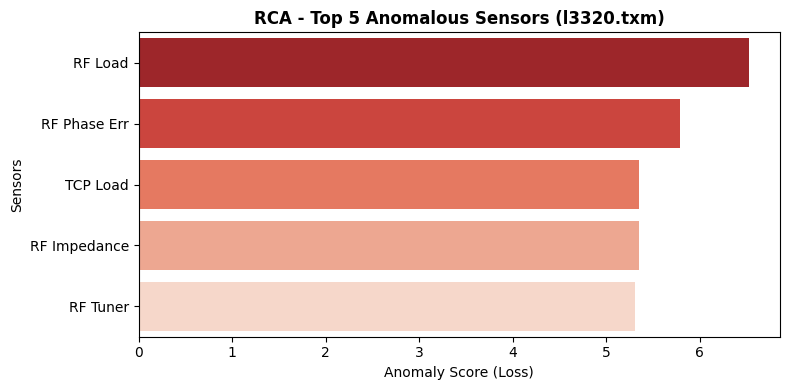

  1위. RF Load: 6.5327
  2위. RF Phase Err: 5.7902
  3위. TCP Load: 5.3545
  4위. RF Impedance: 5.3500
  5위. RF Tuner: 5.3121


In [6]:
TARGET_EXP_ID = 'l33'
TARGET_WAFER = 'l3320.txm'
save_dir = "/content/drive/MyDrive/ASK_2026_FDC/Code/최종 코드/Saved"
data_file_path = "/content/drive/MyDrive/ASK_2026_FDC/Dataset/MACHINE_Data.xlsx" # 원본 데이터 경로

model_path = f"{save_dir}/trace_gpt_{TARGET_EXP_ID}.pth"
meta_path = f"{save_dir}/metadata_{TARGET_EXP_ID}.pkl"

if not os.path.exists(model_path) or not os.path.exists(meta_path):
    print("❌ 저장된 모델/메타데이터가 없습니다.")
else:
    # 1. 메타데이터 (Threshold, Scaler 포함) 로드
    with open(meta_path, 'rb') as f:
        loaded_meta = pickle.load(f)

    config = loaded_meta['config']
    threshold = loaded_meta['threshold']
    sensor_cols = loaded_meta['sensor_cols']
    scaler = loaded_meta['scaler']
    SEQ_LEN = 32

    # 2. 모델 로드 및 가중치 주입
    loaded_model = TRACE_GPT(
        num_sensors=len(sensor_cols), seq_len=SEQ_LEN-1,
        d_model=config['d_model'], resolution=config['resolution']
    ).to(device)
    loaded_model.load_state_dict(torch.load(model_path, map_location=device))
    loaded_model.eval()

    # 3. 원본 데이터에서 타겟 웨이퍼 Raw Data 추출
    print(f"원본 데이터 로드 중: {data_file_path}")
    raw_df = pd.read_excel(data_file_path) if data_file_path.endswith('.xlsx') else pd.read_csv(data_file_path)
    target_df = raw_df[raw_df['Wafer_ID'] == TARGET_WAFER]

    if target_df.empty:
        print(f"❌ 원본 데이터에서 '{TARGET_WAFER}' 웨이퍼를 찾을 수 없습니다.")
    else:
        # 4. 실시간 전처리 (Scaling & Windowing)
        print("⚙️ 데이터 스케일링 및 슬라이딩 윈도우 변환 중...")
        target_tensor = preprocess_and_window(target_df, sensor_cols, SEQ_LEN, scaler)

        # 5. 분석 실행
        if target_tensor is not None:
            target_tensor = target_tensor.to(device)
            analyze_single_wafer(
                model=loaded_model,
                wafer_tensor=target_tensor,
                wafer_id=TARGET_WAFER,
                threshold=threshold,
                sensor_cols=sensor_cols,
                device=device,
                resolution=config['resolution']
            )